In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pylab as plt
from sklearn.linear_model import LinearRegression

In [17]:
df = pd.read_csv("Final Data.csv")
df

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100210.95,1973,5,4,7.6,23.0,11.9,5220.00,1,0,0,40275084.00
1,100210.95,1560,3,3,6.3,13.0,15.8,3882.00,1,0,13,26812029.00
2,100210.95,2071,4,3,5.8,9.0,21.1,4488.00,0,0,9,29315677.00
3,100210.95,2640,5,3,7.7,12.0,7.9,3614.00,1,1,4,46250249.55
4,100210.95,1498,3,3,3.8,15.0,24.0,2663.00,0,0,15,17724566.00
...,...,...,...,...,...,...,...,...,...,...,...,...
4195,103990.05,1328,4,2,4.9,21.0,19.6,2606.00,1,0,21,18319188.00
4196,103990.05,2363,6,4,6.9,50.0,24.9,4013.00,1,0,14,40340976.00
4197,103990.05,632,2,2,4.5,27.0,19.4,1268.00,1,0,6,6189628.85
4198,103990.05,606,2,2,7.5,26.0,11.6,1026.75,0,0,9,7916191.00


In [18]:
df.columns


Index(['house_id', 'area_sqft', 'bedrooms', 'bathrooms', 'location_score',
       'age_years', 'distance_city_km', 'lot_size_sqft', 'has_garage',
       'has_pool', 'renovation_years_ago', 'house_price_inr'],
      dtype='object')

### Independent columns

In [19]:
X = df[["bedrooms"]]

In [20]:
X

,bedrooms
0,5
1,3
2,4
3,5
4,3
...,...
4195,4
4196,6
4197,2
4198,2


### Dependent columns

In [21]:
y = df[["house_price_inr"]]

In [22]:
y

,house_price_inr
0,40275084.00
1,26812029.00
2,29315677.00
3,46250249.55
4,17724566.00
...,...
4195,18319188.00
4196,40340976.00
4197,6189628.85
4198,7916191.00


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
X_train

,bedrooms
2417,6
3827,4
239,5
3633,5
1543,2
...,...
3444,5
466,4
3092,3
3772,2


In [25]:
X_test

,bedrooms
1743,4
2196,4
1728,5
3337,2
298,3
...,...
152,2
1948,4
2751,6
2148,3


In [26]:
y_train

,house_price_inr
2417,28039339.0
3827,36655898.0
239,19744745.0
3633,21812311.0
1543,19444280.0
...,...
3444,19409041.0
466,23372689.0
3092,22461733.0
3772,8848343.0


In [27]:
y_test

,house_price_inr
1743,36890986.0
2196,27836840.0
1728,15321534.0
3337,30812774.0
298,18194835.0
...,...
152,20918771.0
1948,44375916.0
2751,22099538.0
2148,22898162.0


In [28]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
y_pred = model.predict(X_test)

In [36]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE Score:", mean_squared_error(y_test, y_pred))
print("RMSE Score:",np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE Score:", mean_absolute_error(y_test, y_pred))
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2_score(y_test, y_pred))*(n - 1)/(n - p - 1)

print("Adjusted R2:", adj_r2)

R2 Score: 0.4005490736572196
MSE Score: 74790240744099.95
RMSE Score: 8648135.102095708
MAE Score: 7124896.896330725
Adjusted R2: 0.39983373842292025


In [ ]:
bedroom = float(input("Enter house bedroom number: "))
predicted_price = model.predict([[bedroom]])
print("Predicted House Price:", predicted_price[0])

Predicted House Price: [29816291.98585237]


C:\Users\lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [33]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)

Intercept: [5384178.47049915]
Coefficient: [[4886422.70307064]]


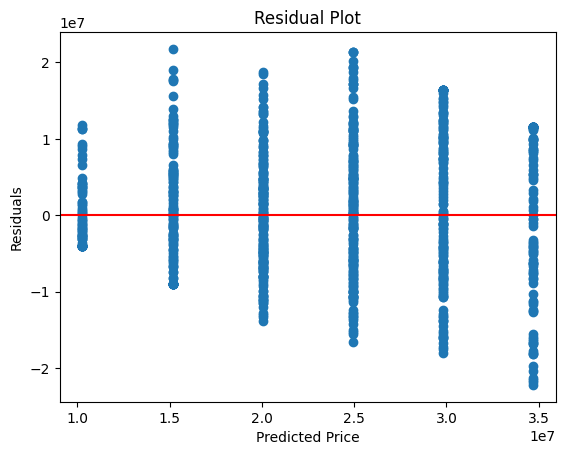

In [37]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()